# **Model Building - XGBoost**

In [1]:
import pandas as pd 
train = pd.read_csv('/kaggle/input/datasets/sanyazuberi/ev-charging-train-test-split/train.csv', index_col=0, parse_dates=True)
test = pd.read_csv('/kaggle/input/datasets/sanyazuberi/ev-charging-train-test-split/test.csv', index_col=0, parse_dates=True)

train.index.freq = 'h'
test.index.freq = 'h'

**Import XGBoost**  
No installation is required, as it is pre-installed in the working environment. 

In [2]:
from xgboost import XGBRegressor

import matplotlib.dates as mdates
import matplotlib.pyplot as plt 

from sklearn.metrics import mean_absolute_percentage_error , root_mean_squared_error

**Define a reusable training/evaluation function**  
As with Prophet, a single function (run_xgboost) handles training, predictions, and metric calculation for any target/feature-list combination, avoiding duplicated code between session and energy runs.

In [3]:
def run_xgboost(train_df, test_df, target_col, feature_cols):
  x_train = train_df[feature_cols]
  y_train = train_df[target_col]

  x_test = test_df[feature_cols]
  y_test = test_df[target_col]

  model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
  model.fit(x_train, y_train)

  predictions = model.predict(x_test)

  rmse = root_mean_squared_error(y_test, predictions)
  nonzero_mask = y_test != 0
  mape = mean_absolute_percentage_error(y_test[nonzero_mask],
                                        predictions[nonzero_mask])

  return model, predictions, rmse, mape

**Feature set 1: Lag-based**  
The initial feature set included calendar features (hour, day of week, month, weekend flag) alongside lag features (1-hour, 24-hour, 168-hour) and a 7-day rolling average, separately for each target. 

In [4]:
session_features = ['hour', 'day_of_week', 'month', 'is_weekend',
                    'lag_1h_session_count', 'lag_24h_session_count', 'lag_168h_session_count',
                    'rolling_7d_avg_session_count']

energy_features = ['hour', 'day_of_week', 'month', 'is_weekend',
                    'lag_1h_energy', 'lag_24h_energy', 'lag_168h_energy',
                    'rolling_7d_avg_energy']

**Run both targets: lag-based features**

In [5]:
model_session_xgb, pred_session_xgb, rmse_session_xgb, mape_session_xgb = run_xgboost(
    train, test, 'session_count', session_features
)

model_energy_xgb, pred_energy_xgb, rmse_energy_xgb, mape_energy_xgb = run_xgboost(
    train, test, 'total_energy_kwh', energy_features
)

**Plotting actual vs. predicted: Session Count (lag-based)**

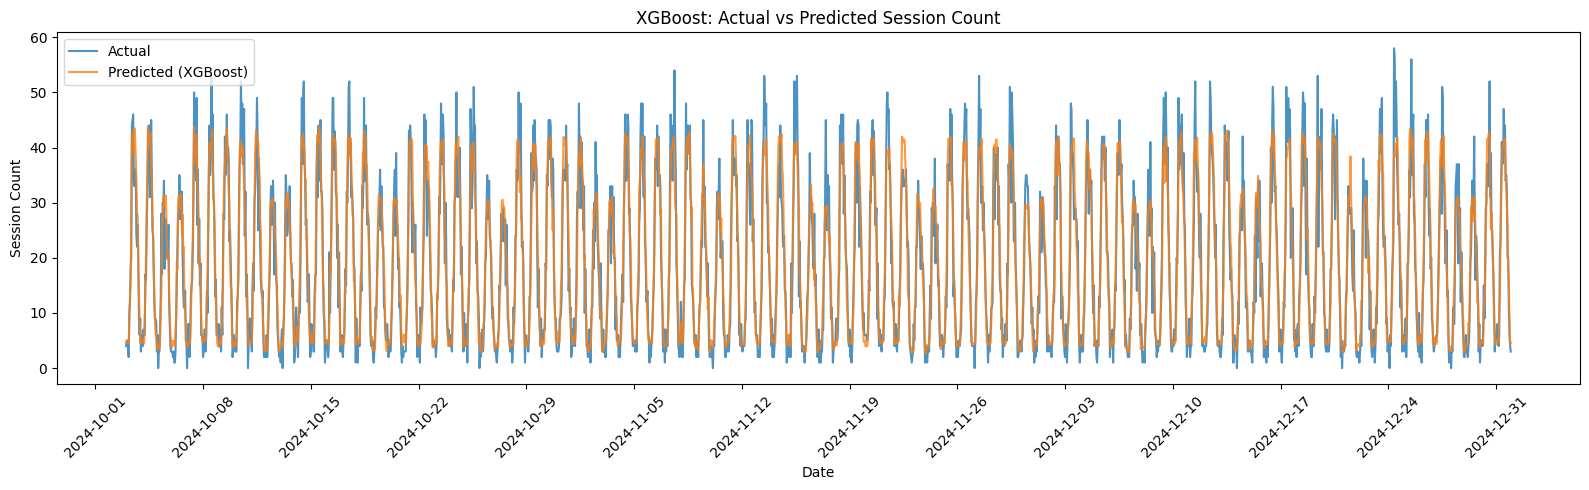

In [6]:
plt.figure(figsize=(16, 5))
plt.plot(test.index, test['session_count'], label='Actual', alpha=0.8)
plt.plot(test.index, pred_session_xgb, label='Predicted (XGBoost)', alpha=0.8)
plt.legend()
plt.title('XGBoost: Actual vs Predicted Session Count')
plt.xlabel('Date')
plt.ylabel('Session Count')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The predicted line closely tracks both timing and the magnitude of the daily demand cycle. Peaks on both actual and predicted lines regularly reach into the high 40s and low 50s, and the predicted line follows the sharp overnight-to-midday rise and the evening decline with minimal lag. Unlike SARIMA, there's no systematic compression at the high end. Predicted peaks sit close to actual peaks on most days, rather than consistently falling short. Some individual days still show a visible gap (predicted running a few sessions below actual on the highest-demand days), but this is noticeably tighter than either Prophet's or SARIMA's fit on the same dataa, and is consistent with this being the lowest-RMSE result across all models tested. 

**Plotting actual vs. predicted: Energy (kWh) (lag-based)**

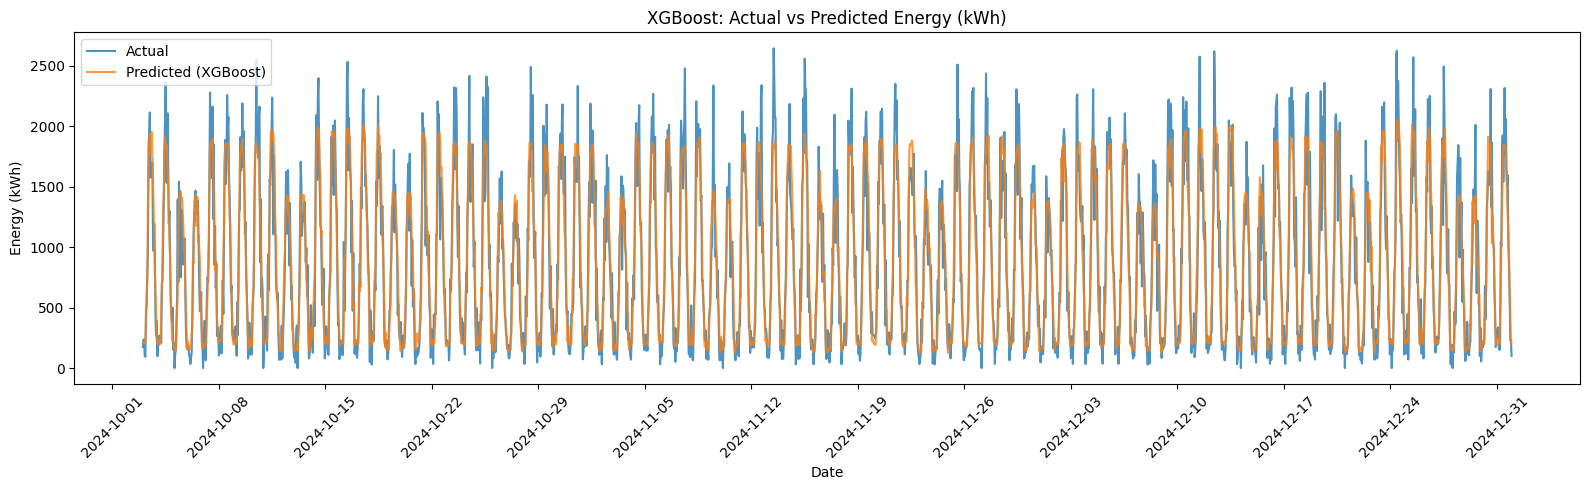

In [7]:
plt.figure(figsize=(16, 5))
plt.plot(test.index, test['total_energy_kwh'], label='Actual', alpha=0.8)
plt.plot(test.index, pred_energy_xgb, label='Predicted (XGBoost)', alpha=0.8)
plt.legend()
plt.title('XGBoost: Actual vs Predicted Energy (kWh)')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The same close tracking holds for energy. Predicted peaks regularly reach into 2,000+ kWh range on high-demand days, closely matching actual peak values, and the daily rise-and-fall shape is well preserved. This is a clear improvement over SARIMA's energy predictions, which plateaued around ~1,800 kWh regardless of how high actual demand climbed. As with session count, the fit isn't perfect on every single day, some peaks are still lsightly underestimated, but there's no consistent, systematic ceiling the way there was with SARIMA.

**Results: lag-based features**

In [8]:
results_xgboost = pd.DataFrame({
    'target': ['session_count', 'total_energy_kwh'],
    'RMSE': [rmse_session_xgb, rmse_energy_xgb],
    'MAPE': [mape_session_xgb, mape_energy_xgb]
})
results_xgboost

,target,RMSE,MAPE
0,session_count,4.709003,0.328190
1,total_energy_kwh,230.927404,0.354101


RMSE of 4.71 for session count and 230.93 for energy, with MAPE of 0.328 and 0.354 respectively (MAPE excluding zero-demand hours, consistent with the other models). This is the lowest error of any model version built in this notebook. Both RMSE figures are meaningfully below Prophet's (5.31/262.1) and SARIMA's (5.46 / 264.7). However, as noted above, this result relied on lag features built from real values inside the test window, so it isn't a fair comparison to the other models and is retained here as a reference point only. 

**Feature set 2: Calendar only version**  
The lag-based version above produced the lowest error of any model tested, but it isn't uable for the actual goal of the task. Its lag features are built from real values inside the test window, information that genuinely doesn't exist when forecasting dates that haven't happened yet. A forecast for, say, day 45 of a 90-day horizon would need the actual demand from day 44, 21, and 38 days earlier within that same forecast, which the model itself hasn't generated yet at that point. This makes the lag-based result a strong indicator of the model's underlying capability, but not one that can be deployed for real forecasting without a recursive, error-compounding workaround.  
To get a result that's both fair to compare against Prophet and SARIMA (which forecast the entire test period blind, with no access to real values from within it) and actually deployable for the 30/90/365-day forecast this project requires, a second version was built using only calendar features all of which are known in advance for any date, part or future. This sacrifices some accuray relative to the lag-based version, but produces a model that can genuinely forecast forward in time without relying on information that won't exist yet.

In [9]:
# Calendar-only XGBoost (no lag features; fair for future forecasting) 
train['year'] = train.index.year
test['year'] = test.index.year

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend', 'year']

model_session_xgb_cal, pred_session_xgb_cal, rmse_session_xgb_cal, mape_session_xgb_cal = run_xgboost(
    train, test, 'session_count', calendar_features
)
model_energy_xgb_cal, pred_energy_xgb_cal, rmse_energy_xgb_cal, mape_energy_xgb_cal = run_xgboost(
    train, test, 'total_energy_kwh', calendar_features
)

**Plotting actual vs. predicted: Session Count (calendar-only)**

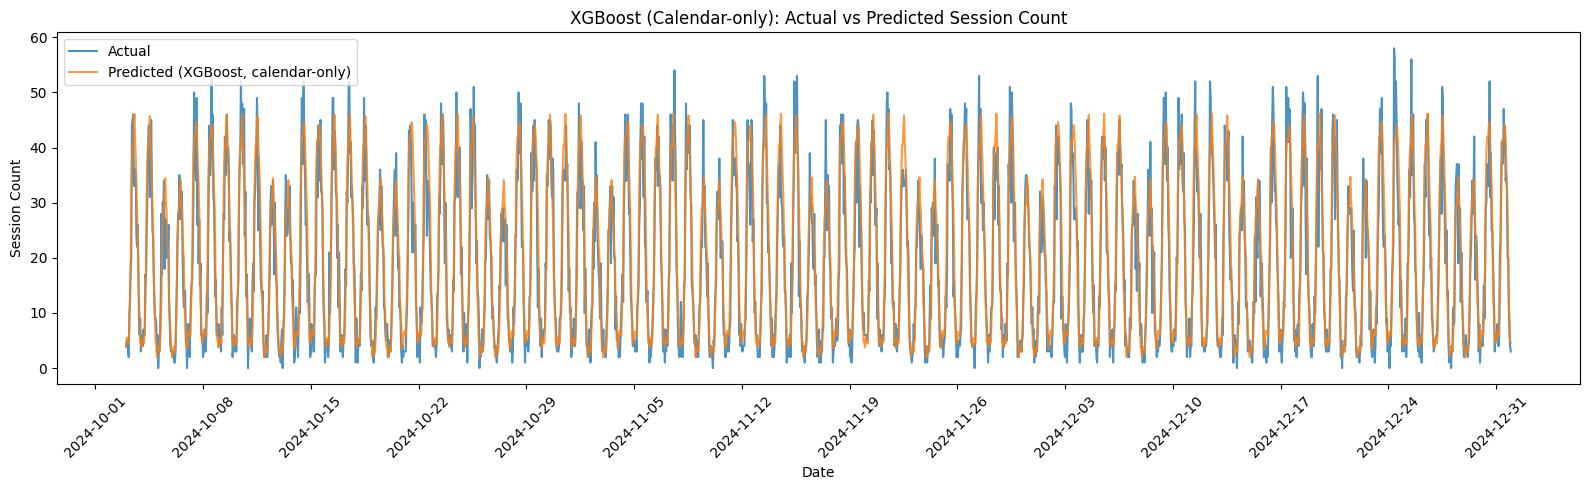

In [10]:
plt.figure(figsize=(16,5))
plt.plot(test.index, test['session_count'], label='Actual', alpha=0.8)
plt.plot(test.index, pred_session_xgb_cal, label='Predicted (XGBoost, calendar-only)', alpha=0.8)
plt.legend()
plt.title('XGBoost (Calendar-only): Actual vs Predicted Session Count')
plt.xlabel('Date')
plt.ylabel('Session Count')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

With the lag features removed, meaning the model has no access to what actually happened in the previous hour, day, week, the fit holds up well. Peak timing and rough peak height still aslign closely with actual demand across the full test period, and the weekly weekday/weekend patterns remains clearly visible. Compared to the lab-based version, there's slightly more scatter around the sharper peaks and a bit more day-to-day variability in how closely the predicted line hugs the actual one. The overall shape and magnitude of the daily cycle are still well captured using calendar information alone.

**Plotting actual vs. predicted: Energy (kWh) (calendar-only)**

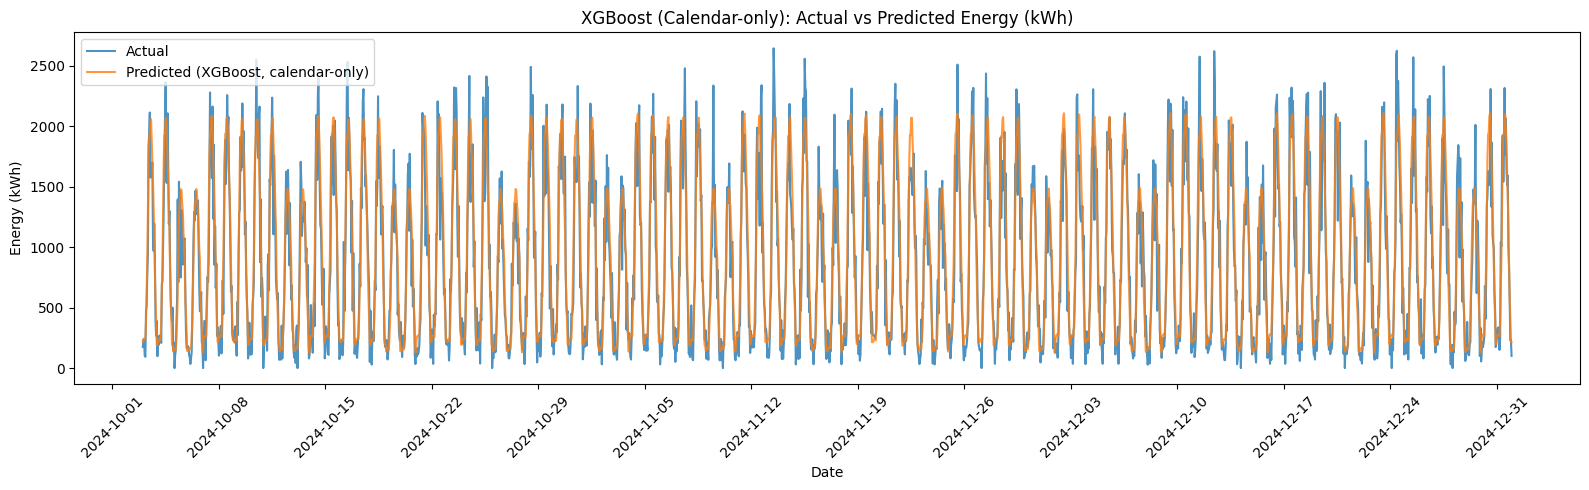

In [11]:
plt.figure(figsize=(16,5))
plt.plot(test.index, test['total_energy_kwh'], label='Actual', alpha=0.8)
plt.plot(test.index, pred_energy_xgb_cal, label='Predicted (XGBoost, calendar-only)', alpha=0.8)
plt.legend()
plt.title('XGBoost (Calendar-only): Actual vs Predicted Energy (kWh)')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The same pattern holds for energy, predicted peaks continue to reach close to actual peaks, regularly nearing or exceeding 2,000 kWh, without the pronounced compression seen in SARIMA's forecasts. The fit is close to, though marginally less tight than, the lag-based energy graph, with slightly more spread visible during the highest-demand periods. This is expected, since the model is now working from a coarser set of signals (calendar position plus year), rather than direct knowledge of recent energy usage.   

**Results: calendar-only features**

In [12]:
results_xgboost_calendar = pd.DataFrame({
    'target': ['session_count', 'total_energy_kwh'],
    'RMSE': [rmse_session_xgb_cal, rmse_energy_xgb_cal],
    'MAPE': [mape_session_xgb_cal, mape_energy_xgb_cal]
})
results_xgboost_calendar

,target,RMSE,MAPE
0,session_count,4.983864,0.349952
1,total_energy_kwh,233.893227,0.369924


RMSE of 4.98 for session count and 233.89 for energy, with MAPE of 0.350 and 0.370 respectively. This is a modest increase in error compared to the lag-based version (RMSE 4.71/230.93, MAPE 0.328/0.354), rough a 6% rise in session RMSE and 1% in energy RMSE. This is a small cost for a model that no longer depends on information unavailable at true forecast time. This version is the one carried forward into the final model comparison and used for generating the 30/90/365-day forecast, since it reflects the conditions the model will actual operate under.

In [13]:
comparison_session_xgb_cal = pd.DataFrame({
    'ds': test.index,
    'y': test['session_count'],
    'yhat': pred_session_xgb_cal
})
comparison_energy_xgb_cal = pd.DataFrame({
    'ds': test.index,
    'y': test['total_energy_kwh'],
    'yhat': pred_energy_xgb_cal
})

# save output for the next notebook
results_xgboost_calendar.to_csv('/kaggle/working/results_xgboost_calendar.csv', index=False)
comparison_session_xgb_cal.to_csv('/kaggle/working/comparison_session_xgboost_calendar.csv', index=False)
comparison_energy_xgb_cal.to_csv('/kaggle/working/comparison_energy_xgboost_calendar.csv', index=False)